## 1. Import Libraries

In [1]:
import pybamm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
from scipy.interpolate import interp1d
import random
import functools
import matplotlib as mpl
import plotly.graph_objects as go
import pybammeis 
import pickle
from plotly.subplots import make_subplots


import gc
gc.collect()

import logging
# Set the logging level to ERROR to suppress warnings
pybamm.set_logging_level("ERROR")


from utils import *
from eis import *
from params import *
from sensitivity_analysis import *

%load_ext autoreload
%autoreload 2

## 2. EIS Test

### 2.1. PyBaMM

In [2]:
# 1. Models
models = {
    "SPM":  pybamm.lithium_ion.SPM(options={"surface form": "differential", "contact resistance": "true"}),
    "SPMe": pybamm.lithium_ion.SPMe(options={"surface form": "differential", "contact resistance": "true"}),
    "DFN":  pybamm.lithium_ion.DFN(options={"surface form": "differential", "contact resistance": "true"}),
}


# 2. Parameters
base_param = pybamm.ParameterValues("Chen2020")

target_params = {
    "Contact resistance [Ohm]": 0.005
}

params = {
    "SPM":  update_parameters(base_param.copy(), target_params),
    "SPMe": base_param.copy(),
    "DFN":  base_param.copy(),
}


# 3. EIS Setting
eis_info = {
    "freqs_hz"       : np.logspace(np.log10(200e-6), np.log10(1000), 60).tolist(),
    "n_periods"      : 10,
    "dc_offset_a"    : 0.0,
    "ac_mag_a"       : 10e-3,
    "pts_per_period" : 20,
}


# 4. Operating Condition
battery_info = {
    "soc"     : 0.5,
    "T_kelvin": 298.15,
}


# 5. Run EIS and Plot
results = {}
for name, model in models.items():
    results[name] = run_EIS(
        battery_info=battery_info, eis_info=eis_info,
        model=model, name=name,
        param=params[name]
    )

plot_nyquist(list(results.values()))

  SOC=0.50 | T=298.1K | 0.0002 Hz ✅  (0.2s)
  SOC=0.50 | T=298.1K | 0.0002598 Hz ✅  (0.1s)
  SOC=0.50 | T=298.1K | 0.0003374 Hz ✅  (0.2s)
  SOC=0.50 | T=298.1K | 0.0004382 Hz ✅  (0.1s)
  SOC=0.50 | T=298.1K | 0.0005691 Hz ✅  (0.2s)
  SOC=0.50 | T=298.1K | 0.0007392 Hz ✅  (0.2s)
  SOC=0.50 | T=298.1K | 0.00096 Hz ✅  (0.1s)
  SOC=0.50 | T=298.1K | 0.001247 Hz ✅  (0.2s)
  SOC=0.50 | T=298.1K | 0.001619 Hz ✅  (0.1s)
  SOC=0.50 | T=298.1K | 0.002103 Hz ✅  (0.1s)
  SOC=0.50 | T=298.1K | 0.002732 Hz ✅  (0.1s)
  SOC=0.50 | T=298.1K | 0.003548 Hz ✅  (0.1s)
  SOC=0.50 | T=298.1K | 0.004608 Hz ✅  (0.1s)
  SOC=0.50 | T=298.1K | 0.005985 Hz ✅  (0.1s)
  SOC=0.50 | T=298.1K | 0.007773 Hz ✅  (0.1s)
  SOC=0.50 | T=298.1K | 0.0101 Hz ✅  (0.1s)
  SOC=0.50 | T=298.1K | 0.01311 Hz ✅  (0.1s)
  SOC=0.50 | T=298.1K | 0.01703 Hz ✅  (0.1s)
  SOC=0.50 | T=298.1K | 0.02212 Hz ✅  (0.1s)
  SOC=0.50 | T=298.1K | 0.02873 Hz ✅  (0.1s)
  SOC=0.50 | T=298.1K | 0.03731 Hz ✅  (0.2s)
  SOC=0.50 | T=298.1K | 0.04846 Hz ✅  (

### 2.2. PyBaMM + PyBaMM-EIS

In [3]:
models = {
    "SPM":  pybamm.lithium_ion.SPM(options={"surface form": "differential", "contact resistance": "true"}),
    "SPMe": pybamm.lithium_ion.SPMe(options={"surface form": "differential", "contact resistance": "true"}),
    "DFN":  pybamm.lithium_ion.DFN(options={"surface form": "differential", "contact resistance": "true"}),
}

contact_resistances = {
    "SPM":  0.005,  # 0.015 Ω
    "SPMe": 0,
    "DFN":  0,
}

base_param = pybamm.ParameterValues("Chen2020")
base_param.update({
    "Ambient temperature [K]": 298.15,
    "Initial concentration in negative electrode [mol.m-3]":
        0.5 * base_param["Maximum concentration in negative electrode [mol.m-3]"],
    "Initial concentration in positive electrode [mol.m-3]":
        0.5 * base_param["Maximum concentration in positive electrode [mol.m-3]"],
})

freqs = np.logspace(np.log10(200e-6), np.log10(1000), 60)

fig = go.Figure()

for name, model in models.items():
    param = base_param.copy()
    param["Contact resistance [Ohm]"] = contact_resistances[name]

    eis_sim = pybammeis.EISSimulation(model, parameter_values=param)
    impedance = eis_sim.solve(freqs)
    Z = impedance * 1000  # Ω → mΩ

    fig.add_trace(go.Scatter(
        x    = Z.real,
        y    = -Z.imag,
        mode = "lines+markers",
        name = name,
    ))
    print(f"✅ {name} done")


font_size = 36
fig.update_layout(
    title  = dict(text="Nyquist Plot", font=dict(size=font_size)),
    xaxis  = dict(
        title     = dict(text="Re(Z) [mΩ]", font=dict(size=font_size)),
        tickfont  = dict(size=font_size),
        range     = [0, 60],
        scaleanchor = "y",
        scaleratio  = 1,
    ),
    yaxis  = dict(
        title    = dict(text="-Im(Z) [mΩ]", font=dict(size=font_size)),
        tickfont = dict(size=font_size),
        range    = [0, 40],
    ),
    legend = dict(x=0.01, y=0.99, font=dict(size=font_size)),
    width  = 12 * 96,
    height = 9 * 96,
)

fig.show()

✅ SPM done
✅ SPMe done
✅ DFN done


## 3. C-rate Dependence

### 3.1. PyBaMM + PyBaMM-EIS  :  PyBaMM-EIS cannot capture C-rate dependence

In [4]:
# 1. Model & Parameters (SPMe 사용)
model = pybamm.lithium_ion.SPMe(options={"surface form": "differential", "contact resistance": "true"})
base_param = pybamm.ParameterValues("Chen2020")

# 초기 농도 세팅 (SOC 0.5 수준)
base_param.update({
    "Ambient temperature [K]": 298.15,
    "Initial concentration in negative electrode [mol.m-3]": 
        0.5 * base_param["Maximum concentration in negative electrode [mol.m-3]"],
    "Initial concentration in positive electrode [mol.m-3]": 
        0.5 * base_param["Maximum concentration in positive electrode [mol.m-3]"],
    "Contact resistance [Ohm]": 0.005  # 필요 시 설정
})

# 2. EIS 주파수 설정
freqs = np.logspace(np.log10(200e-6), np.log10(1000), 60)

# 3. C-rate(전류 크기) 스윕 설정
ac_mags = [10e-3, 1000e-3, 2000e-3, 3000e-3, 4000e-3, 5000e-3, 2*5000e-3, 3*5000e-3, 4*5000e-3, 5*5000e-3]

fig = go.Figure()

# 4. 루프 실행
for ac_mag in ac_mags:
    # 단위에 맞춰 Label 생성 (기존 로직 유지)
    if ac_mag >= 1.0:
        label = f"{ac_mag:.1f} A"
    else:
        label = f"{ac_mag*1000:.0f} mA"

    # 파라미터 업데이트 (전류 크기 반영)
    param = base_param.copy()
    # pybammeis는 내부적으로 ac_mag을 처리하므로, 직접 시뮬레이션 인자로 넘깁니다.
    
    print(f"🚀 Running EIS at {label}...")
    
    # pybammeis 핵심 실행부
    # 주석: pybammeis는 선형화된 모델을 풀기 때문에 사실상 ac_mag에 의한 
    # 비선형 효과(포화 등)는 시뮬레이션 방식에 따라 차이가 날 수 있습니다.
    eis_sim = pybammeis.EISSimulation(model, parameter_values=param)
    
    # solve 시점에 ac_mag_a를 인자로 전달 (라이브러리 버전에 따라 지원 확인 필요)
    # 일반적으로 주파수 도메인 해석은 선형 응답을 가정하므로 
    # 만약 비선형성을 보려면 타임 도메인 데이터를 다시 주무르거나 모델 옵션을 조정해야 합니다.
    Z_complex = eis_sim.solve(freqs) 
    Z_mOhm = Z_complex * 1000  # Ohm -> mOhm

    # 5. 그래프 추가
    fig.add_trace(go.Scatter(
        x    = Z_complex.real * 1000,
        y    = -Z_complex.imag * 1000,
        mode = "lines+markers",
        name = label,
    ))

# 6. 레이아웃 설정 (기존 스타일 유지)
font_size = 36
fig.update_layout(
    title  = dict(text="Nyquist Plot (SPMe Sweep)", font=dict(size=font_size)),
    xaxis  = dict(
        title     = dict(text="Re(Z) [mΩ]", font=dict(size=font_size)),
        tickfont  = dict(size=font_size),
        range     = [0, 60],
        scaleanchor = "y",
        scaleratio  = 1,
    ),
    yaxis  = dict(
        title    = dict(text="-Im(Z) [mΩ]", font=dict(size=font_size)),
        tickfont = dict(size=font_size),
        range    = [0, 40],
    ),
    legend = dict(x=0.01, y=0.99, font=dict(size=font_size)),
    width  = 12 * 96,
    height = 9 * 96,
)

fig.show()

🚀 Running EIS at 10 mA...
🚀 Running EIS at 1.0 A...
🚀 Running EIS at 2.0 A...
🚀 Running EIS at 3.0 A...
🚀 Running EIS at 4.0 A...
🚀 Running EIS at 5.0 A...
🚀 Running EIS at 10.0 A...
🚀 Running EIS at 15.0 A...
🚀 Running EIS at 20.0 A...
🚀 Running EIS at 25.0 A...


### 3.2. PyBaMM, and then V/I : This can capture C-rate Dependence

In [22]:
# 1. Model
model = pybamm.lithium_ion.SPMe(options={"surface form": "differential", "contact resistance": "true"})

# 2. Parameters
base_param = pybamm.ParameterValues("Chen2020")

# 3. EIS Setting
eis_info_base = {
    "freqs_hz"       : np.logspace(np.log10(200e-6), np.log10(1000), 60).tolist(),
    "n_periods"      : 10,
    "dc_offset_a"    : 0.0,
    "pts_per_period" : 60,
}

# 4. Operating Condition
battery_info = {
    "soc"     : 0.5,
    "T_kelvin": 298.15,
}

# 5. C-rate sweep
ac_mags = [10e-3, 1000e-3, 2000e-3, 3000e-3, 4000e-3, 5000e-3, 2*5000e-3, 3*5000e-3, 4*5000e-3, 5*5000e-3]

results = {}
for ac_mag in ac_mags:
    # 1. 단위를 A 또는 mA로 자동 선택하여 label 생성
    if ac_mag >= 1.0:
        label = f"{ac_mag:.1f} A"
    else:
        label = f"{ac_mag*1000:.0f} mA"
        
    eis_info = {**eis_info_base, "ac_mag_a": ac_mag}
    print(f"\n{'='*40}\n  Running {label}...\n{'='*40}")
    
    # 여기서 name=label로 넘겨주면, plot_nyquist에서 result.get("name")으로 사용됩니다.
    results[label] = run_EIS(
        battery_info=battery_info, eis_info=eis_info,
        model=model, name=label, 
        param=base_param.copy()
    )

plot_nyquist(list(results.values()))


  Running 10 mA...
  SOC=0.50 | T=298.1K | 0.0002 Hz ✅  (1.4s)
  SOC=0.50 | T=298.1K | 0.0002598 Hz ✅  (1.3s)
  SOC=0.50 | T=298.1K | 0.0003374 Hz ✅  (1.0s)
  SOC=0.50 | T=298.1K | 0.0004382 Hz ✅  (0.9s)
  SOC=0.50 | T=298.1K | 0.0005691 Hz ✅  (0.8s)
  SOC=0.50 | T=298.1K | 0.0007392 Hz ✅  (0.7s)
  SOC=0.50 | T=298.1K | 0.00096 Hz ✅  (0.6s)
  SOC=0.50 | T=298.1K | 0.001247 Hz ✅  (0.6s)
  SOC=0.50 | T=298.1K | 0.001619 Hz ✅  (0.5s)
  SOC=0.50 | T=298.1K | 0.002103 Hz ✅  (0.5s)
  SOC=0.50 | T=298.1K | 0.002732 Hz ✅  (0.5s)
  SOC=0.50 | T=298.1K | 0.003548 Hz ✅  (0.4s)
  SOC=0.50 | T=298.1K | 0.004608 Hz ✅  (0.4s)
  SOC=0.50 | T=298.1K | 0.005985 Hz ✅  (0.4s)
  SOC=0.50 | T=298.1K | 0.007773 Hz ✅  (0.4s)
  SOC=0.50 | T=298.1K | 0.0101 Hz ✅  (0.4s)
  SOC=0.50 | T=298.1K | 0.01311 Hz ✅  (0.4s)
  SOC=0.50 | T=298.1K | 0.01703 Hz ✅  (0.4s)
  SOC=0.50 | T=298.1K | 0.02212 Hz ✅  (0.4s)
  SOC=0.50 | T=298.1K | 0.02873 Hz ✅  (0.4s)
  SOC=0.50 | T=298.1K | 0.03731 Hz ✅  (0.4s)
  SOC=0.50 | T=298.

Internal t = 276.733 and h = 1.07832e-14 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 276.733 and h = 1.07832e-14 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 276.733 and h = 1.07832e-14 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 276.733 and h = 4.39396e-15 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 276.733 and h = 4.39396e-15 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 276.733 and h = 4.39396e-15 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 276.733 and h = 4.39396e-15 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 276.733 and h = 4.39396e-15 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 276.733 and h = 4.39396e-15 are such that t + h = t on the 

  SOC=0.50 | T=298.1K | 0.0002 Hz ✅  (8.0s)


Internal t = 226.543 and h = 1.34161e-14 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 226.543 and h = 1.34161e-14 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 226.543 and h = 3.35403e-15 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 226.543 and h = 3.35403e-15 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 226.543 and h = 3.35403e-15 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 226.543 and h = 1.54293e-15 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 226.543 and h = 1.54293e-15 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 226.543 and h = 1.32095e-15 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 226.543 and h = 1.32095e-15 are such that t + h = t on the 

  SOC=0.50 | T=298.1K | 0.0002598 Hz ✅  (8.5s)
  SOC=0.50 | T=298.1K | 0.0003374 Hz ✅  (2.0s)
  SOC=0.50 | T=298.1K | 0.0004382 Hz ✅  (1.8s)
  SOC=0.50 | T=298.1K | 0.0005691 Hz ✅  (1.5s)
  SOC=0.50 | T=298.1K | 0.0007392 Hz ✅  (1.4s)
  SOC=0.50 | T=298.1K | 0.00096 Hz ✅  (1.2s)
  SOC=0.50 | T=298.1K | 0.001247 Hz ✅  (1.2s)
  SOC=0.50 | T=298.1K | 0.001619 Hz ✅  (1.4s)
  SOC=0.50 | T=298.1K | 0.002103 Hz ✅  (1.2s)
  SOC=0.50 | T=298.1K | 0.002732 Hz ✅  (1.1s)
  SOC=0.50 | T=298.1K | 0.003548 Hz ✅  (1.0s)
  SOC=0.50 | T=298.1K | 0.004608 Hz ✅  (1.0s)
  SOC=0.50 | T=298.1K | 0.005985 Hz ✅  (0.9s)
  SOC=0.50 | T=298.1K | 0.007773 Hz ✅  (1.2s)
  SOC=0.50 | T=298.1K | 0.0101 Hz ✅  (3.6s)
  SOC=0.50 | T=298.1K | 0.01311 Hz ✅  (1.2s)
  SOC=0.50 | T=298.1K | 0.01703 Hz ✅  (0.9s)
  SOC=0.50 | T=298.1K | 0.02212 Hz ✅  (0.8s)
  SOC=0.50 | T=298.1K | 0.02873 Hz ✅  (0.8s)
  SOC=0.50 | T=298.1K | 0.03731 Hz ✅  (0.9s)
  SOC=0.50 | T=298.1K | 0.04846 Hz ✅  (0.9s)
  SOC=0.50 | T=298.1K | 0.06294 Hz ✅  

...

  SOC=0.50 | T=298.1K | 0.0002598 Hz ✅  (1.3s)
  SOC=0.50 | T=298.1K | 0.0003374 Hz ✅  (0.5s)


At t = 558.863 and h = 2.18949e-14, the corrector convergence test failed repeatedly or with |h| = hmin.
At t = 362.168 repeated recoverable right-hand side function errors.


  SOC=0.50 | T=298.1K | 0.0004382 Hz ✅  (1.0s)


At t = 557.948 repeated recoverable right-hand side function errors.
At t = 220.274 repeated recoverable right-hand side function errors.
At t = 220.274 repeated recoverable right-hand side function errors.


  SOC=0.50 | T=298.1K | 0.0005691 Hz ✅  (1.1s)
  SOC=0.50 | T=298.1K | 0.0007392 Hz ✅  (0.7s)
  SOC=0.50 | T=298.1K | 0.00096 Hz ✅  (0.5s)
  SOC=0.50 | T=298.1K | 0.001247 Hz ✅  (0.4s)
  SOC=0.50 | T=298.1K | 0.001619 Hz ✅  (0.5s)
  SOC=0.50 | T=298.1K | 0.002103 Hz ✅  (0.8s)
  SOC=0.50 | T=298.1K | 0.002732 Hz ✅  (0.9s)
  SOC=0.50 | T=298.1K | 0.003548 Hz ✅  (1.4s)
  SOC=0.50 | T=298.1K | 0.004608 Hz ✅  (0.6s)
  SOC=0.50 | T=298.1K | 0.005985 Hz ✅  (1.3s)
  SOC=0.50 | T=298.1K | 0.007773 Hz ✅  (1.5s)
  SOC=0.50 | T=298.1K | 0.0101 Hz ✅  (1.6s)
  SOC=0.50 | T=298.1K | 0.01311 Hz ✅  (1.2s)
  SOC=0.50 | T=298.1K | 0.01703 Hz ✅  (1.3s)
  SOC=0.50 | T=298.1K | 0.02212 Hz ✅  (1.3s)
  SOC=0.50 | T=298.1K | 0.02873 Hz ✅  (1.2s)
  SOC=0.50 | T=298.1K | 0.03731 Hz ✅  (1.0s)
  SOC=0.50 | T=298.1K | 0.04846 Hz ✅  (1.0s)
  SOC=0.50 | T=298.1K | 0.06294 Hz ✅  (1.0s)
  SOC=0.50 | T=298.1K | 0.08175 Hz ✅  (1.2s)
  SOC=0.50 | T=298.1K | 0.1062 Hz ✅  (0.9s)
  SOC=0.50 | T=298.1K | 0.1379 Hz ✅  (0.8s)
 

In [23]:
# 저장
# with open("SOC50_C_rate.pkl", "wb") as f:
#     pickle.dump(results, f)
# print("✅ Saved: SOC50_C_rate.pkl")


with open("SOC50_C_rate.pkl", "rb") as f:
    results_C_rate = pickle.load(f)

In [27]:
plot_nyquist_filtered(list(results_C_rate.values()))

  ✅ 10 mA: 60/60 points valid
  ✅ 1.0 A: 60/60 points valid
  ✅ 2.0 A: 60/60 points valid
  ✅ 3.0 A: 60/60 points valid
  ✅ 4.0 A: 60/60 points valid
  ✅ 5.0 A: 60/60 points valid
  ⚠️ 10.0 A | 0.0002598 Hz → not sinusoidal (zero crossings=1), stopping
  ✅ 10.0 A: 58/60 points valid
  ⚠️ 15.0 A | 0.001619 Hz → not sinusoidal (zero crossings=6), stopping
  ✅ 15.0 A: 51/60 points valid
  ⚠️ 20.0 A | 0.004608 Hz → voltage out of range, stopping
  ✅ 20.0 A: 47/60 points valid
  ⚠️ 25.0 A | 0.007773 Hz → voltage out of range, stopping
  ✅ 25.0 A: 45/60 points valid


## 4. SOC Dependent (10 mA)

In [8]:
# 1. Model
model = pybamm.lithium_ion.SPMe(options={"surface form": "differential", "contact resistance": "true"})

# 2. Parameters
base_param = pybamm.ParameterValues("Chen2020")

# 3. EIS Setting
eis_info = {
    "freqs_hz"       : np.logspace(np.log10(200e-6), np.log10(1000), 60).tolist(),
    "n_periods"      : 10,
    "dc_offset_a"    : 0.0,
    "ac_mag_a"       : 10e-3,
    "pts_per_period" : 60,
}

# 4. SOC → theta 매핑 (한 번만 계산)
soc2theta_n, soc2theta_p = build_soc2theta(base_param.copy())

# 5. SOC sweep
soc_list = [0.98, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.02]

results = {}
for soc in soc_list:
    label = f"SOC={soc*100:.0f}%"
    battery_info = {"soc": soc, "T_kelvin": 298.15}
    print(f"\n{'='*40}\n  Running {label}...\n{'='*40}")
    results[label] = run_EIS(
        battery_info=battery_info, eis_info=eis_info,
        model=model, name=label,
        param=base_param.copy(),
        soc2theta_n=soc2theta_n, soc2theta_p=soc2theta_p
    )

plot_nyquist(list(results.values()))


  Running SOC=98%...
  SOC=0.98 | T=298.1K | 0.0002 Hz ✅  (1.0s)
  SOC=0.98 | T=298.1K | 0.0002598 Hz ✅  (0.9s)
  SOC=0.98 | T=298.1K | 0.0003374 Hz ✅  (0.8s)
  SOC=0.98 | T=298.1K | 0.0004382 Hz ✅  (0.7s)


SystemError: <built-in function Function_call> returned a result with an exception set

In [26]:
# with open("SOC_sweep_10mA.pkl", "wb") as f:
#     pickle.dump(results, f)

# print("✅ Saved: SOC_sweep_10mA.pkl")



with open("SOC_sweep_10mA.pkl", "rb") as f:
    results_SOC = pickle.load(f)

In [30]:
plot_nyquist(list(results_SOC.values()))

## 5. Sensitivity Analysis

### 5.1. Sensitivity Calculation

In [41]:
# 1. Model
model = pybamm.lithium_ion.SPMe(options={"surface form": "differential", "contact resistance": "true"})

# 2. Parameters
base_param = pybamm.ParameterValues("Chen2020")

# 3. Target params
target_params = [
    # Charge transfer
    "Negative electrode exchange-current density [A.m-2]", # k^-
    "Positive electrode exchange-current density [A.m-2]", # k^+

    # Double-layer
    "Negative electrode double-layer capacity [F.m-2]", # C_dl^n
    "Positive electrode double-layer capacity [F.m-2]", # C_dl^p
    "Negative electrode active material volume fraction", # eps_s_^-
    "Positive electrode active material volume fraction", # eps_s_^+

    # Electrolyte
    "Cation transference number", # t_+
    "Electrolyte conductivity [S.m-1]", # kappa
    "Electrolyte diffusivity [m2.s-1]", # D_e
    "Positive electrode porosity", # eps_e^+
    "Negative electrode porosity", # eps_e^-
    "Separator porosity", # eps_e^sep
    "Negative electrode thickness [m]", # L^-
    "Positive electrode thickness [m]", # L^+
    "Separator thickness [m]", # L^sep

    # Anode Particle
    "Negative particle diffusivity [m2.s-1]", # D_s^-
    "Negative particle radius [m]", # R_s^-

    # Cathode Particle
    "Positive particle diffusivity [m2.s-1]", # D_s^+
    "Positive particle radius [m]", # R_s^+
]

# 4. SOC → theta (한 번만)
soc2theta_n, soc2theta_p = build_soc2theta(base_param.copy())

# 5. Run sensitivity
freqs = [1000, 100, 10, 1, 0.1, 0.01, 0.001, 0.0001]
soc = 0.7
perturbation = 0.05
ac_mag = 15



filename = f"sensitivity_results_{ac_mag}A_soc{int(soc*100)}.pkl"  

results_sensitivity = {}
for freq in freqs:
    current_fn, t_eval = make_sinusoidal_input(
        freq_hz=freq, n_periods=10, dc_offset_a=0.0,
        ac_mag_a=ac_mag, pts_per_period=60
    )
    results_sensitivity[freq] = {"t_eval": t_eval}
    freq_failed = False

    for param in target_params:
        print(f"  freq={freq}Hz | {param}...")
        try:
            sensitivity, V_nominal = compute_sensitivity(
                model, base_param.copy(),
                current_fn=current_fn, t_eval=t_eval,
                target_param=param, soc=soc, perturbation=perturbation,
                soc2theta_n=soc2theta_n, soc2theta_p=soc2theta_p
            )
            results_sensitivity[freq][param] = {
                "sensitivity": sensitivity,
                "V_nominal"  : V_nominal,
            }
            print(f"  ✅ done")
        except Exception as e:
            print(f"  ❌ failed at freq={freq}Hz | {param}: {e}")
            results_sensitivity[freq][param] = None
            freq_failed = True
            break

    if freq_failed:
        print(f"  ⚠️ freq={freq}Hz 에서 중단, 이하 주파수 스킵")
        with open(filename, "wb") as f:
            pickle.dump(results_sensitivity, f)
        print(f"✅ Saved (partial): {filename}")
        for remaining_freq in freqs[freqs.index(freq)+1:]:
            results_sensitivity[remaining_freq] = None
        break

# 6. Save
with open(filename, "wb") as f:
    pickle.dump(results_sensitivity, f)
print(f"✅ Saved: {filename}")

  freq=1000Hz | Negative electrode exchange-current density [A.m-2]...
  ✅ done
  freq=1000Hz | Positive electrode exchange-current density [A.m-2]...
  ✅ done
  freq=1000Hz | Negative electrode double-layer capacity [F.m-2]...
  ✅ done
  freq=1000Hz | Positive electrode double-layer capacity [F.m-2]...
  ✅ done
  freq=1000Hz | Negative electrode active material volume fraction...
  ✅ done
  freq=1000Hz | Positive electrode active material volume fraction...
  ✅ done
  freq=1000Hz | Cation transference number...
  ✅ done
  freq=1000Hz | Electrolyte conductivity [S.m-1]...
  ✅ done
  freq=1000Hz | Electrolyte diffusivity [m2.s-1]...
  ✅ done
  freq=1000Hz | Positive electrode porosity...
  ✅ done
  freq=1000Hz | Negative electrode porosity...
  ✅ done
  freq=1000Hz | Separator porosity...
  ✅ done
  freq=1000Hz | Negative electrode thickness [m]...
  ✅ done
  freq=1000Hz | Positive electrode thickness [m]...
  ✅ done
  freq=1000Hz | Separator thickness [m]...
  ✅ done
  freq=1000Hz | Ne

At t = 208.039 and h = 2.9759e-12, the corrector convergence test failed repeatedly or with |h| = hmin.
At t = 378.101 and h = 2.50439e-10, the corrector convergence test failed repeatedly or with |h| = hmin.
Internal t = 222.826 and h = 2.81075e-15 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 222.826 and h = 2.81075e-15 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 222.826 and h = 1.02077e-14 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 222.826 and h = 1.02077e-14 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 222.826 and h = 5.17221e-15 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 222.826 and h = 5.17221e-15 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 222.826 and h = 5.17221e-15 are such that t + h = t on the next step. The solver w

  ✅ done
  freq=0.0001Hz | Positive electrode exchange-current density [A.m-2]...


At t = 208.039 and h = 2.9759e-12, the corrector convergence test failed repeatedly or with |h| = hmin.
At t = 388.618 repeated recoverable right-hand side function errors.
Internal t = 214.648 and h = 1.07793e-14 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 214.648 and h = 1.07793e-14 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 214.648 and h = 2.69481e-15 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 214.648 and h = 2.69481e-15 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 214.648 and h = 2.69481e-15 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 214.648 and h = 2.69481e-15 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 214.648 and h = 2.69481e-15 are such that t + h = t on the next step. The solver will continue anyway.
Internal t = 21

  ✅ done
  freq=0.0001Hz | Negative electrode double-layer capacity [F.m-2]...


...

At t = 208.039 and h = 2.9759e-12, the corrector convergence test failed repeatedly or with |h| = hmin.
At t = 368.016 repeated recoverable right-hand side function errors.
At t = 395.703 repeated recoverable right-hand side function errors.


  ✅ done
  freq=0.0001Hz | Positive particle radius [m]...


At t = 208.039 and h = 2.9759e-12, the corrector convergence test failed repeatedly or with |h| = hmin.
At t = 212.953 and h = 1.52778e-13, the corrector convergence test failed repeatedly or with |h| = hmin.


  ✅ done
✅ Saved: sensitivity_results_15A_soc70.pkl


At t = 347.588 repeated recoverable right-hand side function errors.


### 5.2. RMS calculation

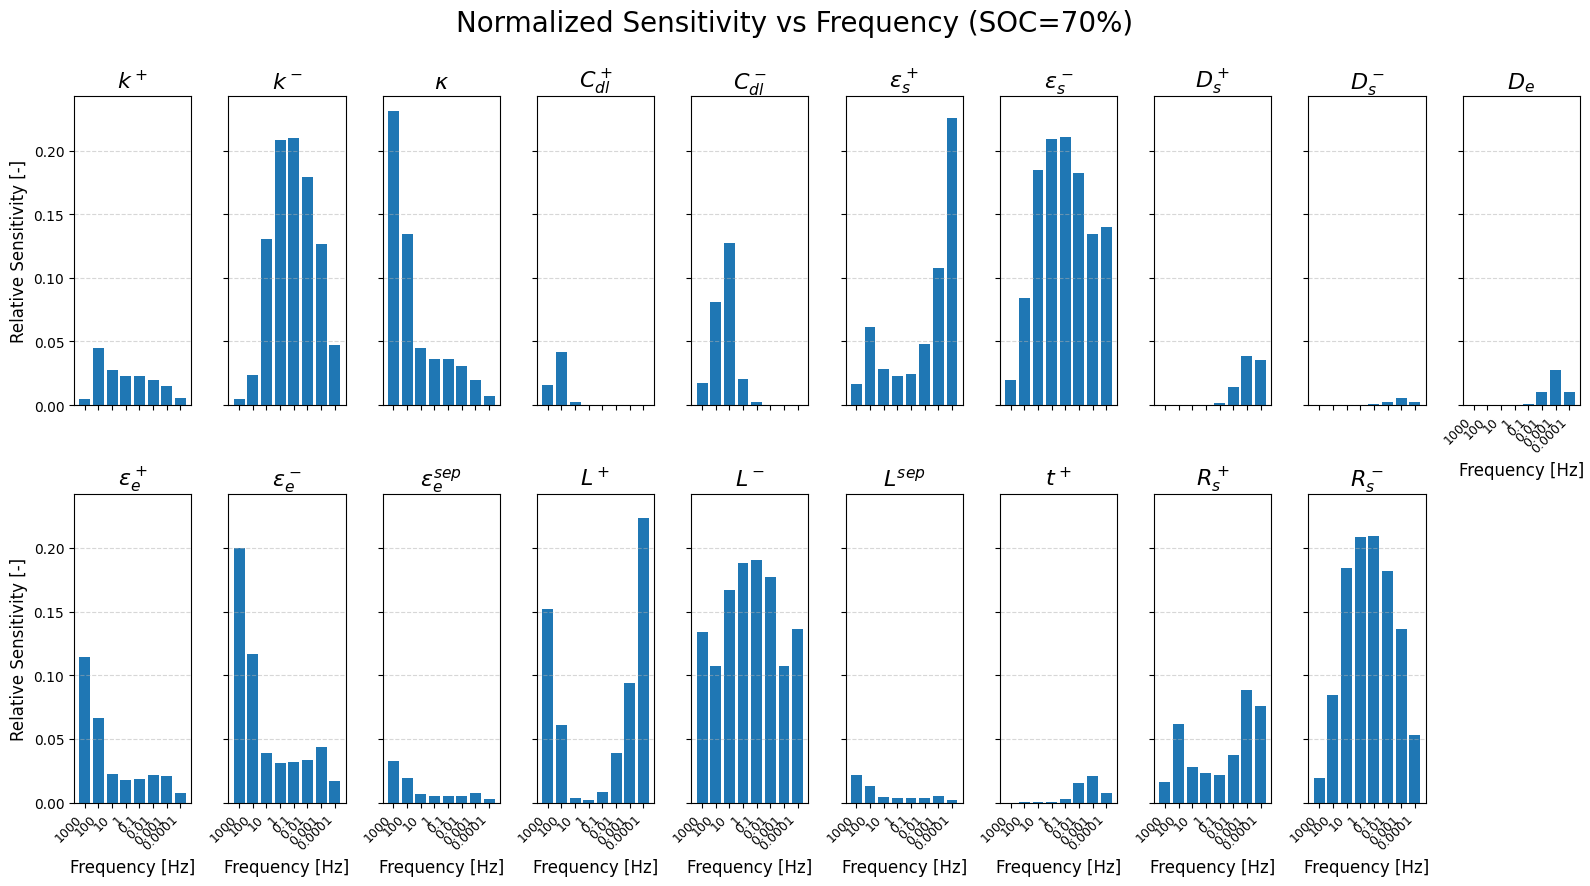

In [ ]:
# 1. Load
with open("sensitivity_results_100mA_soc70.pkl", "rb") as f:
    results_sensitivity = pickle.load(f)

freqs = [1000, 100, 10, 1, 0.1, 0.01, 0.001, 0.0001]

target_params = [
    # 1-10
    "Positive electrode exchange-current density [A.m-2]",
    "Negative electrode exchange-current density [A.m-2]",
    "Electrolyte conductivity [S.m-1]",

    "Positive electrode double-layer capacity [F.m-2]",
    "Negative electrode double-layer capacity [F.m-2]",

    "Positive electrode active material volume fraction",
    "Negative electrode active material volume fraction",

    "Positive particle diffusivity [m2.s-1]",
    "Negative particle diffusivity [m2.s-1]",
    "Electrolyte diffusivity [m2.s-1]",



    # 11-19
    "Positive electrode porosity",
    "Negative electrode porosity",
    "Separator porosity",

    "Positive electrode thickness [m]",
    "Negative electrode thickness [m]",
    "Separator thickness [m]",

    "Cation transference number",

    "Positive particle radius [m]",
    "Negative particle radius [m]",
]


# 2. Calculate RMS
S, S_bar = compute_rms_sensitivity(results_sensitivity, freqs, target_params)


# 4. Plot
n_params = len(target_params)
n_cols = 10
n_rows = int(np.ceil(n_params / n_cols))

freq_labels = [str(f) for f in freqs]
x = np.arange(len(freqs))

# 각 컬럼의 마지막 인덱스
last_in_col = {}
for i in range(n_params):
    col = i % n_cols
    last_in_col[col] = i

# 각 로우의 첫 번째 인덱스
first_in_row = {}
for i in range(n_params):
    row = i // n_cols
    if row not in first_in_row:
        first_in_row[row] = i

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 9),
                         sharex=True, sharey=True)
axes = axes.flatten()

for i, param in enumerate(target_params):
    ax  = axes[i]
    row = i // n_cols
    col = i %  n_cols

    y = [S_bar[freq][param] for freq in freqs]
    ax.bar(x, y)
    ax.set_title(get_symbol(param), fontsize=16)
    ax.set_xticks(x)
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)

    if i == first_in_row[row]:
        ax.set_ylabel("Relative Sensitivity [-]", fontsize=12)

    if i == last_in_col[col]:
        ax.tick_params(labelbottom=True)  # 강제로 켜기
        ax.set_xticklabels(freq_labels, fontsize=9, rotation=45, ha='right')
        ax.set_xlabel("Frequency [Hz]", fontsize=12)
    else:
        ax.tick_params(labelbottom=False)

# 빈 subplot 숨기기
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Normalized Relative Sensitivity vs Frequency (SOC=70%)", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

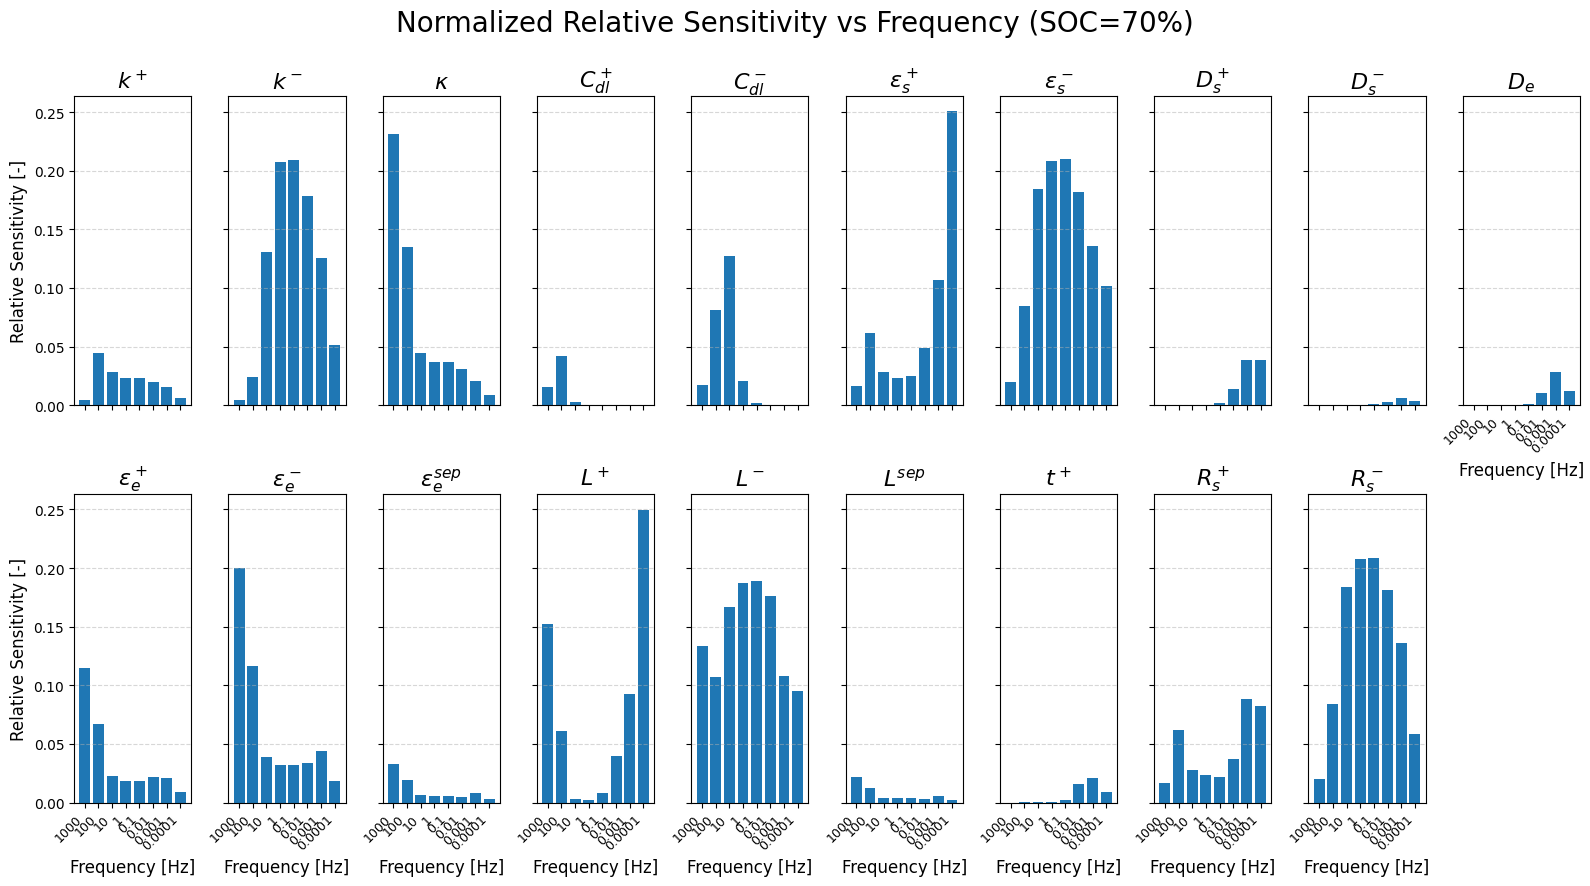

In [31]:
# 1. Load
with open("sensitivity_results_0.1C_soc70.pkl", "rb") as f:
    results_sensitivity = pickle.load(f)

freqs = [1000, 100, 10, 1, 0.1, 0.01, 0.001, 0.0001]

target_params = [
    # 1-10
    "Positive electrode exchange-current density [A.m-2]",
    "Negative electrode exchange-current density [A.m-2]",
    "Electrolyte conductivity [S.m-1]",

    "Positive electrode double-layer capacity [F.m-2]",
    "Negative electrode double-layer capacity [F.m-2]",

    "Positive electrode active material volume fraction",
    "Negative electrode active material volume fraction",

    "Positive particle diffusivity [m2.s-1]",
    "Negative particle diffusivity [m2.s-1]",
    "Electrolyte diffusivity [m2.s-1]",



    # 11-19
    "Positive electrode porosity",
    "Negative electrode porosity",
    "Separator porosity",

    "Positive electrode thickness [m]",
    "Negative electrode thickness [m]",
    "Separator thickness [m]",

    "Cation transference number",

    "Positive particle radius [m]",
    "Negative particle radius [m]",
]


# 2. Calculate RMS
S, S_bar = compute_rms_sensitivity(results_sensitivity, freqs, target_params)


# 4. Plot
n_params = len(target_params)
n_cols = 10
n_rows = int(np.ceil(n_params / n_cols))

freq_labels = [str(f) for f in freqs]
x = np.arange(len(freqs))

# 각 컬럼의 마지막 인덱스
last_in_col = {}
for i in range(n_params):
    col = i % n_cols
    last_in_col[col] = i

# 각 로우의 첫 번째 인덱스
first_in_row = {}
for i in range(n_params):
    row = i // n_cols
    if row not in first_in_row:
        first_in_row[row] = i

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 9),
                         sharex=True, sharey=True)
axes = axes.flatten()

for i, param in enumerate(target_params):
    ax  = axes[i]
    row = i // n_cols
    col = i %  n_cols

    y = [S_bar[freq][param] for freq in freqs]
    ax.bar(x, y)
    ax.set_title(get_symbol(param), fontsize=16)
    ax.set_xticks(x)
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)

    if i == first_in_row[row]:
        ax.set_ylabel("Relative Sensitivity [-]", fontsize=12)

    if i == last_in_col[col]:
        ax.tick_params(labelbottom=True)  # 강제로 켜기
        ax.set_xticklabels(freq_labels, fontsize=9, rotation=45, ha='right')
        ax.set_xlabel("Frequency [Hz]", fontsize=12)
    else:
        ax.tick_params(labelbottom=False)

# 빈 subplot 숨기기
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Normalized Relative Sensitivity vs Frequency (SOC=70%)", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

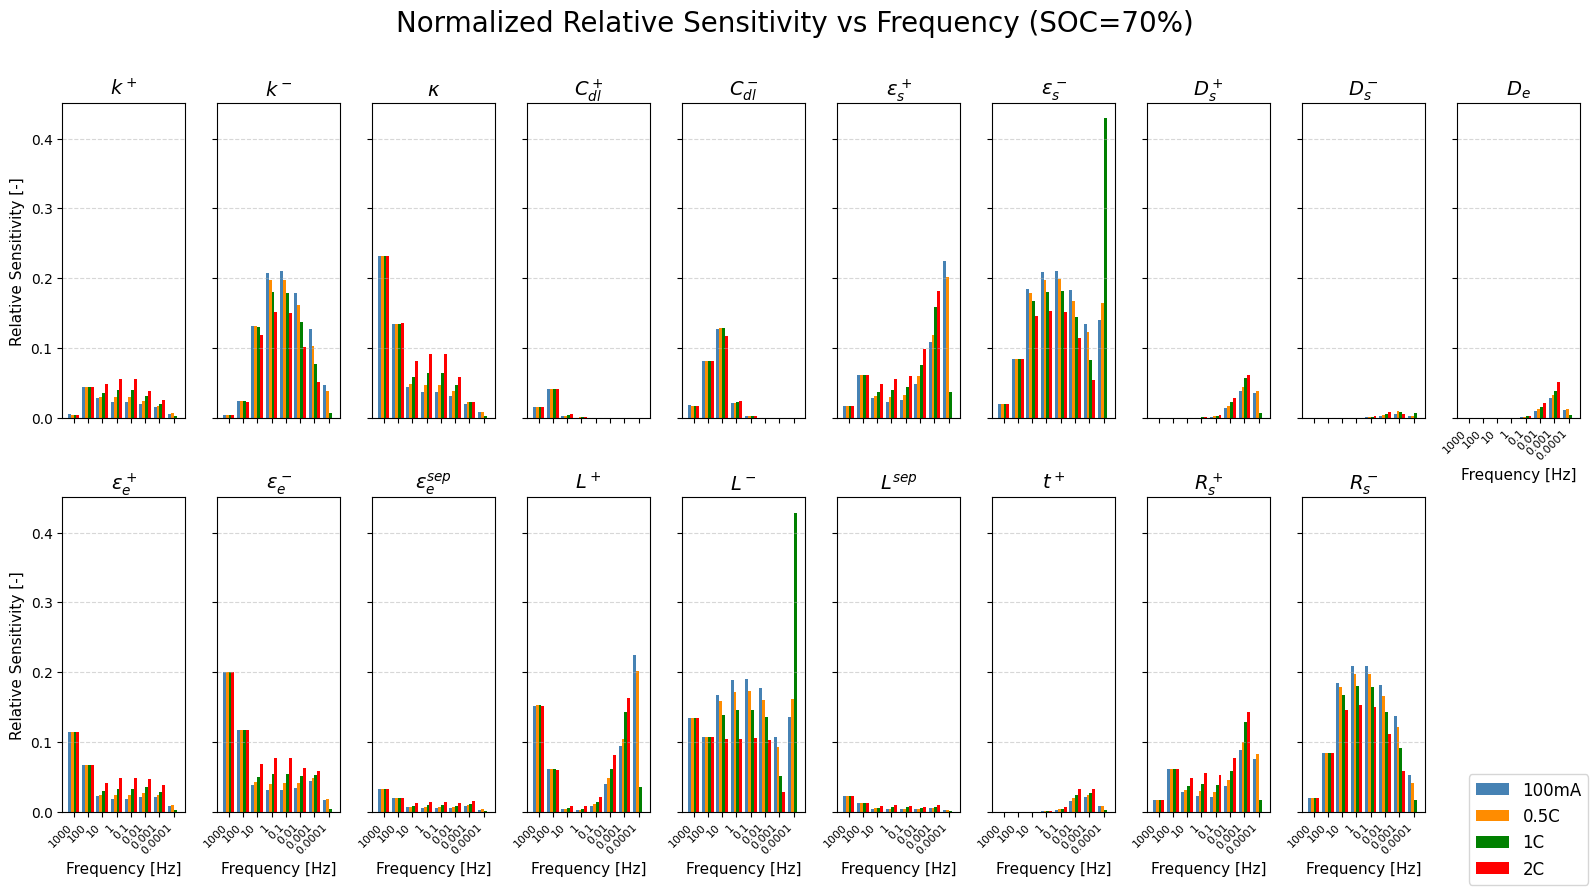

In [40]:
# 1. Load
files = {
    "100mA": "sensitivity_results_100mA_soc70.pkl",
    "0.5C" : "sensitivity_results_0.5C_soc70.pkl",
    "1C"   : "sensitivity_results_1C_soc70.pkl",
    "2C"   : "sensitivity_results_2C_soc70.pkl",
}

data = {}
for label, fname in files.items():
    with open(fname, "rb") as f:
        data[label] = pickle.load(f)

freqs = [1000, 100, 10, 1, 0.1, 0.01, 0.001, 0.0001]

target_params = [
    # 1-10
    "Positive electrode exchange-current density [A.m-2]",
    "Negative electrode exchange-current density [A.m-2]",
    "Electrolyte conductivity [S.m-1]",
    "Positive electrode double-layer capacity [F.m-2]",
    "Negative electrode double-layer capacity [F.m-2]",
    "Positive electrode active material volume fraction",
    "Negative electrode active material volume fraction",
    "Positive particle diffusivity [m2.s-1]",
    "Negative particle diffusivity [m2.s-1]",
    "Electrolyte diffusivity [m2.s-1]",
    # 11-19
    "Positive electrode porosity",
    "Negative electrode porosity",
    "Separator porosity",
    "Positive electrode thickness [m]",
    "Negative electrode thickness [m]",
    "Separator thickness [m]",
    "Cation transference number",
    "Positive particle radius [m]",
    "Negative particle radius [m]",
]

# 2. RMS + normalize per c-rate
S_bar = {}
for label in files:
    S = {}
    for freq in freqs:
        if data[label][freq] is None:
            continue
        S[freq] = {}
        for param in target_params:
            entry = data[label][freq].get(param)
            if entry is None:
                continue
            sens = entry["sensitivity"]
            S[freq][param] = np.sqrt(np.mean(sens**2))

    S_bar[label] = {}
    for freq in S:
        if len(S[freq]) < len(target_params):
            continue
        total = sum(S[freq].values())
        S_bar[label][freq] = {param: S[freq][param] / total for param in target_params}

# 3. valid_freqs: 하나라도 유효한 주파수
valid_freqs = [f for f in freqs if any(f in S_bar[label] for label in files)]
freq_labels = [str(f) for f in valid_freqs]

# 4. Plot
n_params = len(target_params)
n_cols = 10
n_rows = int(np.ceil(n_params / n_cols))

n_crates = len(files)
width = 1.0 / (n_crates + 1)
x = np.arange(len(valid_freqs))
colors = ['steelblue', 'darkorange', 'green', 'red']

last_in_col = {}
for i in range(n_params):
    last_in_col[i % n_cols] = i

first_in_row = {}
for i in range(n_params):
    row = i // n_cols
    if row not in first_in_row:
        first_in_row[row] = i

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 9),
                         sharex=True, sharey=True)
axes = axes.flatten()

for i, param in enumerate(target_params):
    ax  = axes[i]
    row = i // n_cols
    col = i %  n_cols

    for j, (label, color) in enumerate(zip(files.keys(), colors)):
        y = [S_bar[label][freq][param] if freq in S_bar[label] else 0.0
             for freq in valid_freqs]
        ax.bar(x + j * width, y, width=width, color=color,
               label=label if i == 0 else None)

    ax.set_title(get_symbol(param), fontsize=14)
    ax.set_xticks(x + width * (n_crates - 1) / 2)
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)

    if i == first_in_row[row]:
        ax.set_ylabel("Relative Sensitivity [-]", fontsize=11)

    if i == last_in_col[col]:
        ax.tick_params(labelbottom=True)
        ax.set_xticklabels(freq_labels, fontsize=8, rotation=45, ha='right')
        ax.set_xlabel("Frequency [Hz]", fontsize=11)
    else:
        ax.tick_params(labelbottom=False)

# 빈 subplot 숨기기
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.legend(list(files.keys()), loc='lower right', fontsize=12)
fig.suptitle("Normalized Relative Sensitivity vs Frequency (SOC=70%)", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [ ]:
target_params = [
    # 1-10
    "Positive electrode exchange-current density [A.m-2]",
    "Negative electrode exchange-current density [A.m-2]",
    "Electrolyte conductivity [S.m-1]",

    "Positive electrode double-layer capacity [F.m-2]",
    "Negative electrode double-layer capacity [F.m-2]",

    "Positive particle diffusivity [m2.s-1]",
    "Negative particle diffusivity [m2.s-1]",
    "Electrolyte diffusivity [m2.s-1]",
    
    "Positive electrode active material volume fraction",
    "Negative electrode active material volume fraction",


    # 11-19
    "Positive electrode porosity",
    "Negative electrode porosity",
    "Separator porosity",

    "Positive electrode thickness [m]",
    "Negative electrode thickness [m]",
    "Separator thickness [m]",

    "Cation transference number",

    "Positive particle radius [m]",
    "Negative particle radius [m]",
]
